In [1]:
from ultralytics import YOLO
from PIL import Image
import cv2
import torch
import matplotlib.pyplot as plt
import numpy as np


0: 576x640 59 n_ds, 1 d, 26.7ms
Speed: 1.0ms preprocess, 26.7ms inference, 0.6ms postprocess per image at shape (1, 1, 576, 640)


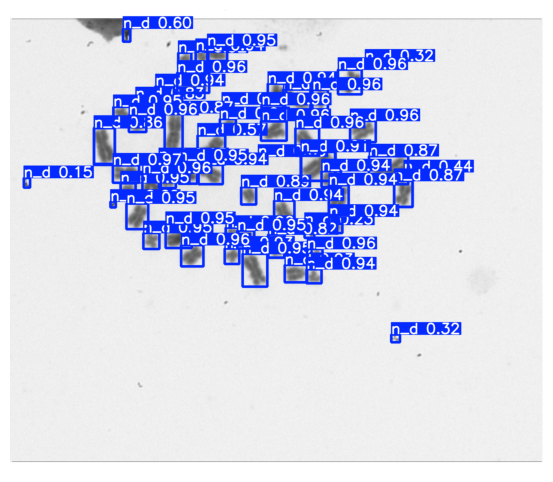

In [3]:
model = YOLO("../runs/detect/fr_raw_x_auto/fold_1_train/weights/best.pt")
img = np.load("../folds/test/raw/val/images/A0017.npy")
results = model.predict(
    source=img, # use np.load()
    save=False,
    show=True,
    visualize=False,
    imgsz=640,
    conf=0.01,
    iou=0.5,
    max_det=60,
)

for i, r in enumerate(results):
    im_bgr = r.plot()  # BGR-order numpy array
    im_rgb = Image.fromarray(im_bgr[..., ::-1])  # RGB-order PIL image

    plt.figure(figsize=(8,6))
    plt.imshow(im_rgb)
    plt.axis("off")
    plt.show()

In [5]:
import torch, gc

gc.collect()  # limpia memoria de Python
torch.cuda.empty_cache()  # libera VRAM cacheada

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch
from ultralytics import YOLO

YOLO_CONF    = 0.5   # confidence threshold passed to YOLO
YOLO_NMS_IOU = 0.5   # NMS IoU threshold passed to YOLO
MATCH_IOU    = 0.5   # IoU to consider a prediction a match for a GT box
GROUP_IOU    = 0.8   # IoU to merge detections from different folds into one group
TARGET_CLASS = 1     # class ID for dicentric chromosomes

# ── Core helpers ───────────────────────────────────────────────────────────────

def calc_iou(a, b):
    """Intersection over Union for two [x1, y1, x2, y2] boxes."""
    x1 = max(a[0], b[0]);  y1 = max(a[1], b[1])
    x2 = min(a[2], b[2]);  y2 = min(a[3], b[3])
    inter  = max(0.0, x2 - x1 + 1) * max(0.0, y2 - y1 + 1)
    area_a = (a[2] - a[0] + 1) * (a[3] - a[1] + 1)
    area_b = (b[2] - b[0] + 1) * (b[3] - b[1] + 1)
    return inter / (area_a + area_b - inter)


def load_gt_boxes(label_path, img_w, img_h):
    """Return GT boxes for TARGET_CLASS as list of [x1, y1, x2, y2]."""
    if not label_path.exists():
        return []
    boxes = []
    for line in label_path.read_text().splitlines():
        parts = line.split()
        if int(parts[0]) != TARGET_CLASS:
            continue
        cx, cy, w, h = map(float, parts[1:])
        boxes.append([
            (cx - w / 2) * img_w,  (cy - h / 2) * img_h,
            (cx + w / 2) * img_w,  (cy + h / 2) * img_h,
        ])
    return boxes


def merge_fold_predictions(predictions):
    """
    Cluster raw (fold_idx, box, conf) detections into groups that refer to
    the same object, based on GROUP_IOU against the group's running mean box.

    Returns a list of dicts: {folds, boxes, confidences, mean_box, mean_conf}.
    """
    groups = []
    for fold_idx, box, conf in predictions:
        box = np.asarray(box, dtype=float)
        for g in groups:
            if calc_iou(box, g['mean_box']) >= GROUP_IOU:
                g['folds'].append(fold_idx)
                g['boxes'].append(box)
                g['confidences'].append(conf)
                g['mean_box']  = np.mean(g['boxes'], axis=0)
                g['mean_conf'] = float(np.mean(g['confidences']))
                break
        else:  # no existing group matched → start a new one
            groups.append({
                'folds':       [fold_idx],
                'boxes':       [box],
                'confidences': [conf],
                'mean_box':    box.copy(),
                'mean_conf':   float(conf),
            })
    return groups


def classify_groups(groups, gt_boxes):
    """
    Assign each prediction group to TP (matches a GT) or FP (no GT match).
    Unmatched GT boxes are returned as FN.

    Returns: (tp_groups, fp_groups, fn_boxes).
    """
    remaining_gt = list(gt_boxes)
    tp_groups, fp_groups = [], []

    for g in groups:
        match = next(
            (gt for gt in remaining_gt if calc_iou(g['mean_box'], gt) >= MATCH_IOU),
            None,
        )
        if match is not None:
            remaining_gt.remove(match)
            tp_groups.append(g)
        else:
            fp_groups.append(g)

    return tp_groups, fp_groups, remaining_gt  # remaining_gt == fn_boxes


# ── Inference ──────────────────────────────────────────────────────────────────

def predict_all(model_paths, labels_dir, image_files):
    """
    Run every model on every image.
    Returns a dict {img_path: {gt_boxes, tp_groups, fp_groups, fn_boxes}}.
    """
    models = [YOLO(p) for p in model_paths]

    results = {}
    for img_path in image_files:
        img_np   = np.load(img_path)
        h, w     = img_np.shape[:2]
        gt_boxes = load_gt_boxes(labels_dir / f"{img_path.stem}.txt", w, h)

        all_preds = []
        for fold_idx, model in enumerate(models):
            r = model.predict(
                source=img_np, save=False, show=False, visualize=False,
                imgsz=640, conf=YOLO_CONF, iou=YOLO_NMS_IOU,
                max_det=60, classes=TARGET_CLASS, verbose=False,
            )[0]
            if r.boxes is not None:
                for box in r.boxes:
                    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                    all_preds.append((fold_idx, [x1, y1, x2, y2], float(box.conf[0])))

        groups     = merge_fold_predictions(all_preds)
        tp, fp, fn = classify_groups(groups, gt_boxes)

        results[img_path] = {
            'gt_boxes':  gt_boxes,
            'tp_groups': tp,
            'fp_groups': fp,
            'fn_boxes':  fn,
        }
    return results


# ── Summary table ──────────────────────────────────────────────────────────────

def print_summary(results):
    W = 65
    print("\n" + "=" * W)
    print(f"{'RESUMEN DE DETECCIONES':^{W}}")
    print("=" * W)
    print(f"{'Imagen':<40}  {'Resultado'}")
    print("-" * W)

    for img_path, res in results.items():
        name = img_path.stem
        if res['tp_groups']:
            # Typically 1 dicentric per image; show folds that voted for it
            folds_s = ", ".join(str(f + 1) for f in sorted(res['tp_groups'][0]['folds']))
            tag = f"Folds {folds_s}"
        elif res['gt_boxes']:
            tag = "Not detected"
        elif res['fp_groups']:
            n = len(res['fp_groups'])
            tag = f"FP sin GT ({n} detección{'es' if n > 1 else ''})"
        else:
            tag = "Sin dicéntrico (correcto)"

        print(f"{name:<40}  {tag}")

    print("=" * W + "\n")


# ── Visualization ──────────────────────────────────────────────────────────────

def _draw_box(ax, box, color, linestyle, label):
    x1, y1, x2, y2 = box
    ax.add_patch(plt.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        fill=False, edgecolor=color, linewidth=2, linestyle=linestyle,
    ))
    ax.text(
        x1, max(y1 - 6, 0), label,
        bbox=dict(facecolor=color, alpha=0.75, pad=2, boxstyle='round,pad=0.3'),
        fontsize=8, color='white', weight='bold',
    )


def visualize_results(results):
    legend_handles = [
        Patch(facecolor='green', label='TP – Detectado correctamente'),
        Patch(facecolor='red',   label='FP – Falso positivo'),
        Patch(facecolor='blue',  label='FN – No detectado'),
    ]

    for img_path, res in results.items():
        img_np = np.load(img_path)
        fig, ax = plt.subplots(figsize=(20, 8))
        ax.imshow(img_np, cmap='gray')
        ax.set_title(img_path.stem, fontsize=12, weight='bold')
        ax.axis('off')

        for g in res['tp_groups']:
            folds_s = ",".join(str(f + 1) for f in sorted(g['folds']))
            _draw_box(ax, g['mean_box'], 'green', '-',
                      f"Folds: {folds_s}  conf: {g['mean_conf']:.2f}")

        for g in res['fp_groups']:
            folds_s = ",".join(str(f + 1) for f in sorted(g['folds']))
            _draw_box(ax, g['mean_box'], 'red', '--',
                      f"FP  Folds: {folds_s}  conf: {g['mean_conf']:.2f}")

        for gt_box in res['fn_boxes']:
            _draw_box(ax, gt_box, 'blue', ':', 'Not detected')

        ax.legend(handles=legend_handles, loc='upper right', fontsize=9)
        plt.tight_layout()
        plt.show()


# ── Heatmap matrix ────────────────────────────────────────────────────────────

def build_detection_matrix(method_results: dict, folds: int = 5) -> pd.DataFrame:
    """
    Build a fold-detection-rate matrix from multiple predict_all outputs.
 
    For each (method, image) cell: fraction of folds that correctly detected
    the dicentric chromosome (TP folds / total folds).
    - Images with no GT dicentric → 0.0 (nothing to detect).
    - Images with multiple dicentrics (rare) → average rate across all GT objects,
      counting undetected ones as 0.0.
 
    Parameters
    ----------
    method_results : {method_name: predict_all_output, ...}
    folds          : total number of folds (denominator)
 
    Returns
    -------
    pd.DataFrame  shape (n_methods × n_images), columns = im1, im2, ...
    """
    # Each method stores results keyed by its own PosixPath (different dirs per method).
    # Normalize to stem so lookups work regardless of which directory was used.
    by_stem = {
        method: {p.stem: res for p, res in results.items()}
        for method, results in method_results.items()
    }
 
    # Canonical image order from the first method
    stems     = list(next(iter(by_stem.values())).keys())
    col_names = [f"im{i + 1}" for i in range(len(stems))]
 
    rows = {}
    for method_name, stem_results in by_stem.items():
        scores = []
        for stem in stems:
            res  = stem_results[stem]
            n_gt = len(res['gt_boxes'])
 
            if n_gt == 0:
                # True negative (no dicentric, nothing detected) → 1.0
                # False positive (no dicentric, but something detected) → 0.0
                scores.append(0.0 if res['fp_groups'] else 1.0)
                continue
 
            # Rate for each GT object: detected folds / folds, or 0.0 if missed
            tp_rates = [len(g['folds']) / folds for g in res['tp_groups']]
            fn_zeros = [0.0] * len(res['fn_boxes'])
            scores.append(float(np.mean(tp_rates + fn_zeros)))
 
        rows[method_name] = scores
 
    return pd.DataFrame(rows, index=col_names).T



def plot_detection_heatmap(df: pd.DataFrame, title: str = "Detección por método e imagen"):
    """
    Render an annotated seaborn heatmap from the matrix produced by
    build_detection_matrix.

    Parameters
    ----------
    df    : output of build_detection_matrix
    title : figure title
    """
    fig, ax = plt.subplots(figsize=(max(8, len(df.columns) * 0.7), len(df) * 0.9 + 1.5))
    sns.heatmap(
        df,
        ax=ax,
        annot=True,
        fmt=".1f",
        cmap="YlOrRd",
        cbar=False,
        vmin=0.0,
        vmax=1.0,
    )
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)
    plt.tight_layout()
    plt.savefig('heatmap.pdf', format='pdf', bbox_inches='tight', dpi=300)
    plt.show()
    #return fig

In [7]:
# ── Configuration ──────────────────────────────────────────────────────────────

folds        = 5
model_paths  = [f"../runs/detect/fr_raw_lt_std_x_auto/fold_{i}_train/weights/best.pt"
                for i in range(1, folds + 1)]
image_dir    = Path("../folds/test/raw_lt_std/val/images/")
label_dir    = Path("../folds/test/raw_lt_std/val/labels/")

# ── Entry point ────────────────────────────────────────────────────────────────
image_files = sorted(image_dir.glob("*.npy"))
for i, im in enumerate(image_files):
    print(im, i+1)
#all_results = predict_all(model_paths, label_dir, image_files)
#print_summary(all_results)
#visualize_results(all_results)

../folds/test/raw_lt_std/val/images/A0017.npy 1
../folds/test/raw_lt_std/val/images/A0044.npy 2
../folds/test/raw_lt_std/val/images/A0048.npy 3
../folds/test/raw_lt_std/val/images/A0053.npy 4
../folds/test/raw_lt_std/val/images/A0203.npy 5
../folds/test/raw_lt_std/val/images/A0224.npy 6
../folds/test/raw_lt_std/val/images/RE05GyCmEaEaP14~A.0258.npy 7
../folds/test/raw_lt_std/val/images/RE05GyCmEaEaP14~A.0273.npy 8
../folds/test/raw_lt_std/val/images/RE075GyCaEaEaP24~A.0177.npy 9
../folds/test/raw_lt_std/val/images/RE15GyCmEaEaP12~A.0123.npy 10
../folds/test/raw_lt_std/val/images/RE15GyCmEaEaP16~A.0114.npy 11
../folds/test/raw_lt_std/val/images/RE15GyCmEaEaP16~A.0131.npy 12
../folds/test/raw_lt_std/val/images/RE3GyCmEaEaP10~A.0011.A.npy 13
../folds/test/raw_lt_std/val/images/RE3GyCmEaEaP10~A.0019.A.npy 14
../folds/test/raw_lt_std/val/images/RE4GyCmEaEaP13~A.0009.npy 15
../folds/test/raw_lt_std/val/images/RE4GyCmEaEaP13~A.0018.npy 16
../folds/test/raw_lt_std/val/images/RE4GyCmEaEaP13~A.0

Processing: max
Processing: clahe
Processing: lbp_mean_std
Processing: lbp_max_std
Processing: raw_lbp_std
Processing: lbp
Processing: raw
Processing: gc
Processing: raw_lt_std
Processing: entropy
Processing: lt
Processing: raw_clahe_lt
Processing: dissimilarity
Processing: lt_clahe_he
Processing: no2
Processing: he
Processing: std
Processing: raw_no2_nc5
Processing: asm
Processing: raw_max_std
Processing: nc5
Processing: energy
Processing: homogeneity
Processing: mean
Processing: contrast
Processing: raw_clahe_std
Processing: lt_clahe_std
               im1  im2  im3  im4  im5  im6  im7  im8  im9  im10  im11  im12  im13  im14      im15  im16  im17  im18  im19  im20  im21  im22  im23  im24  im25  im26  im27
max            0.0  0.0  0.0  0.0  1.0  1.0  0.0  0.4  0.0   1.0   0.0   0.0   0.0   0.0  0.000000   0.3   0.0   0.0   0.0   0.8   0.0   0.8   0.0   0.0   0.0   0.0   0.0
clahe          0.0  0.0  0.2  0.0  1.0  1.0  0.0  0.2  0.0   1.0   0.0   0.0   0.0   0.0  0.000000   0.5   0.0  

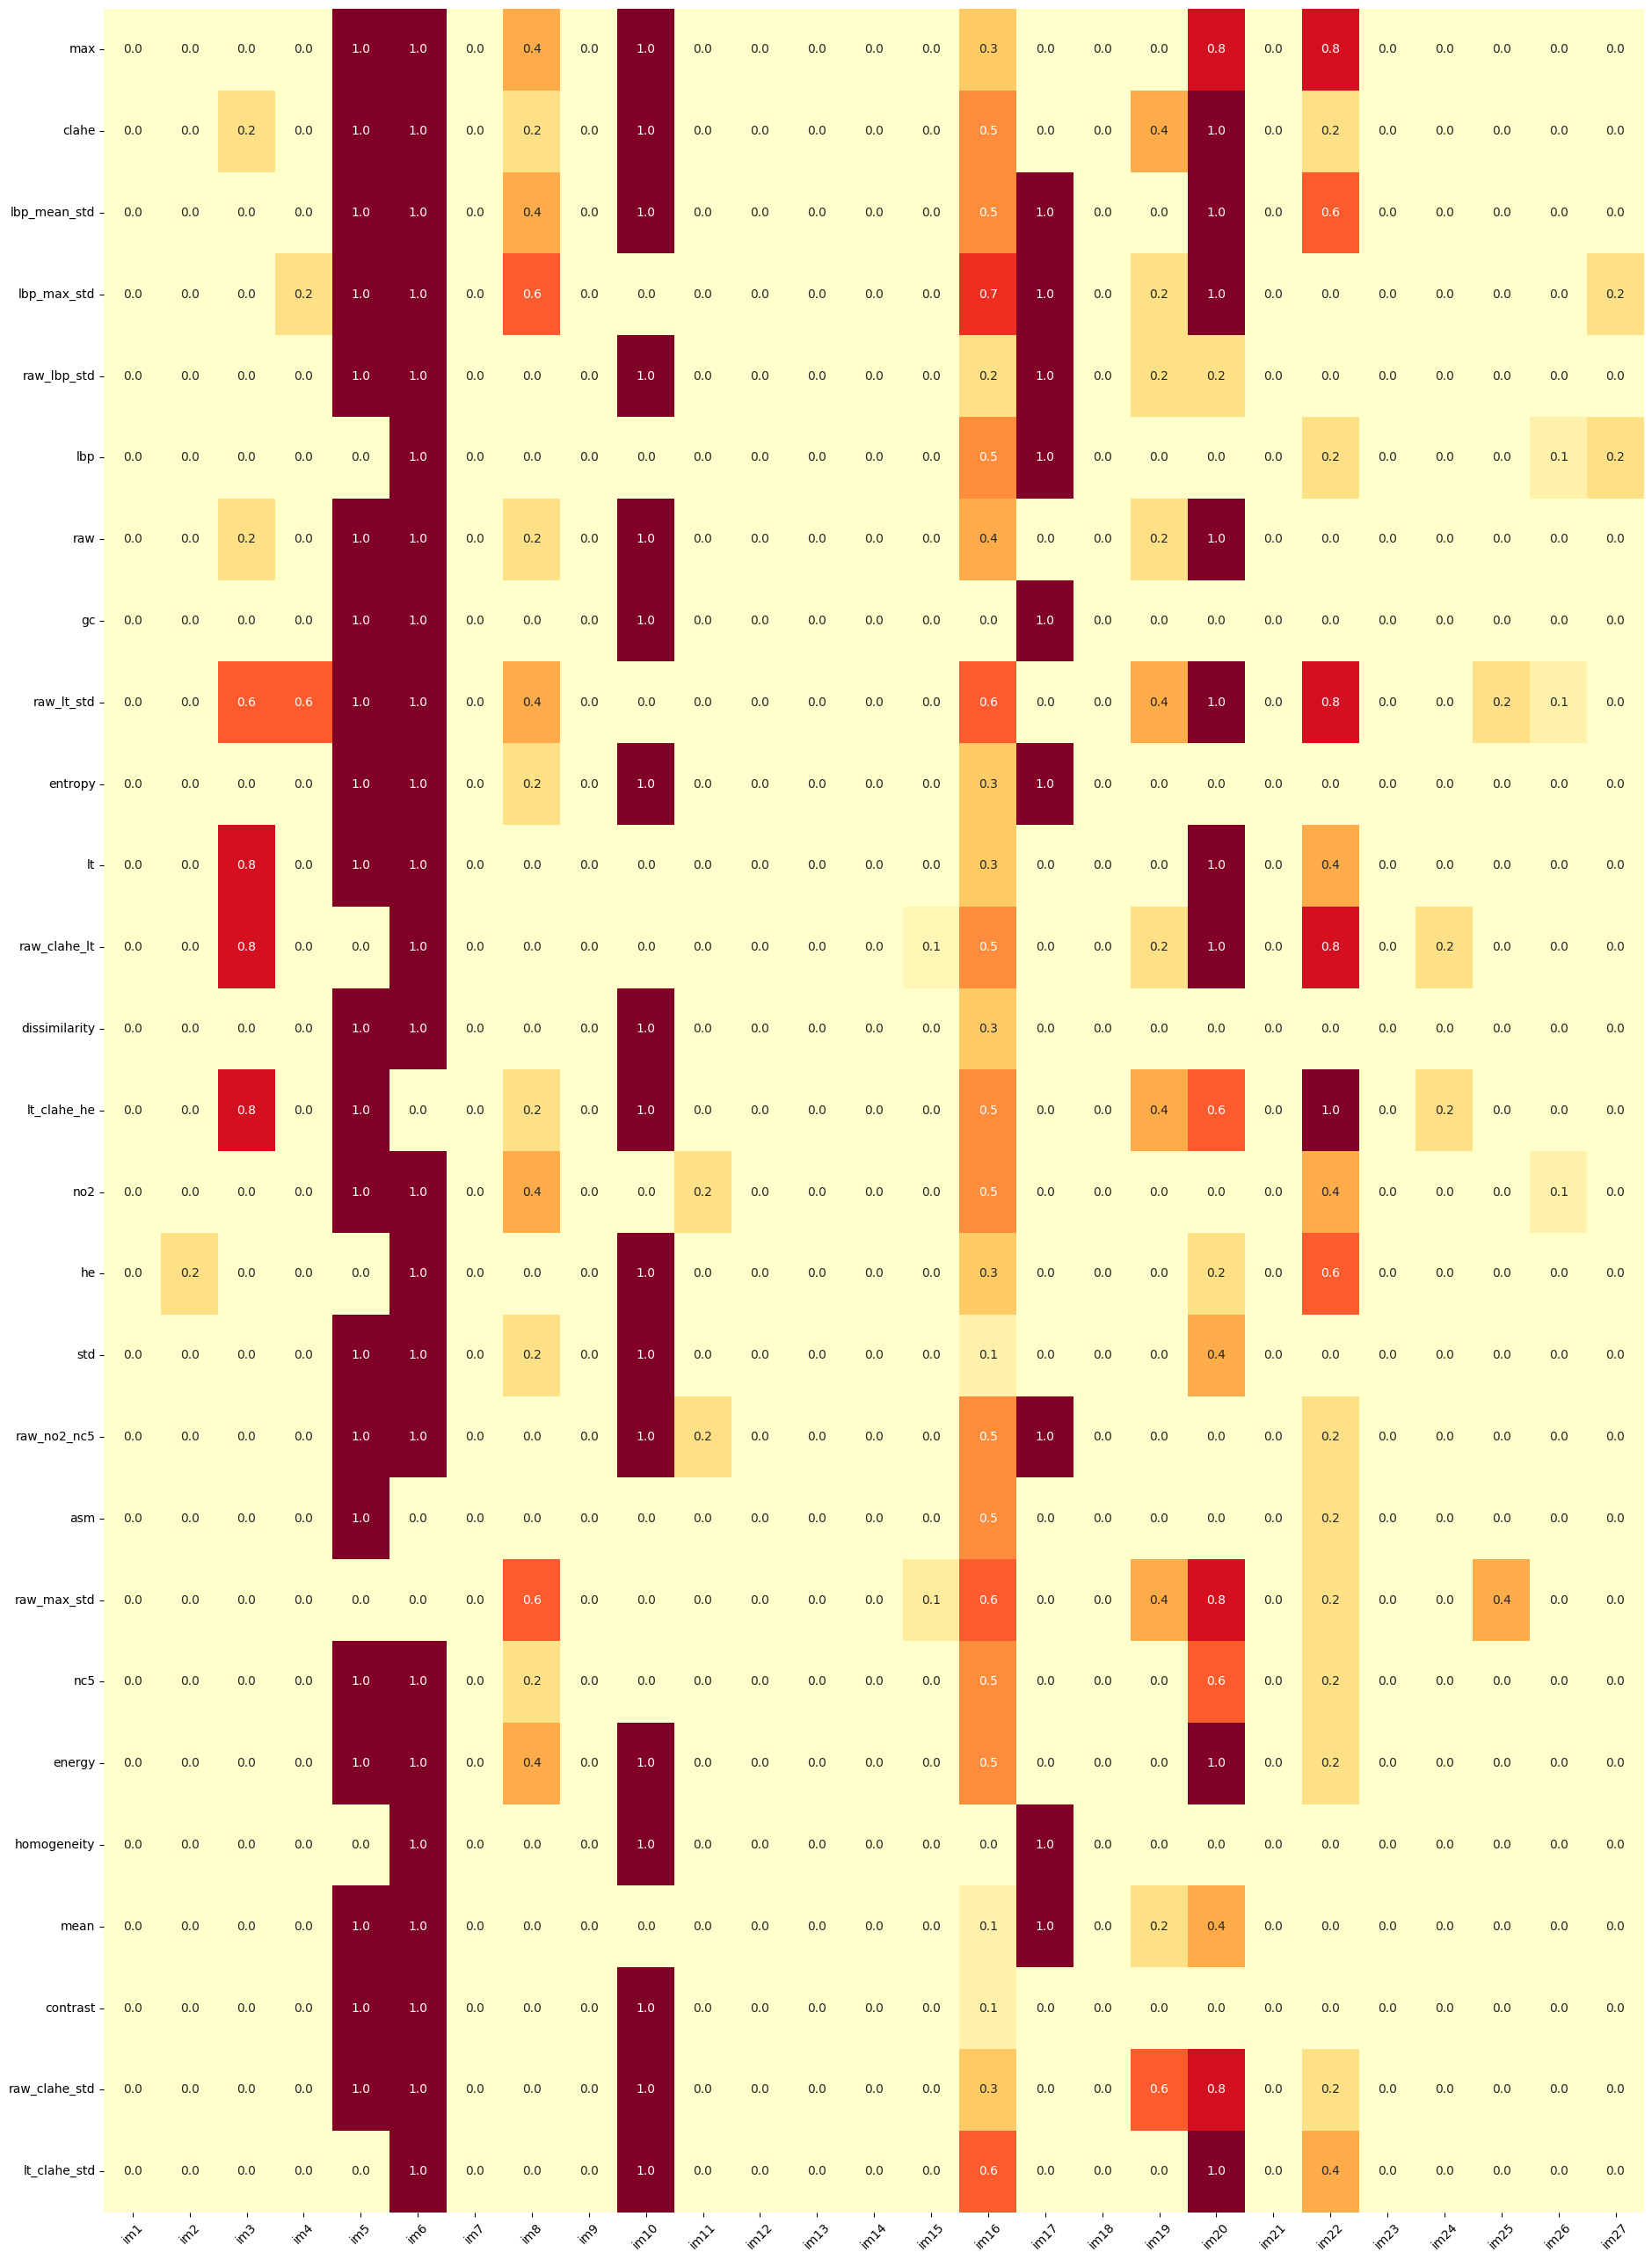

In [9]:
method_results = {}

for i in Path("../folds/test").glob("*"):
    processor = i.stem
    
    if processor == "raw_test":
        continue
    print("Processing:", processor)
    model_paths = [f"../runs/detect/fr_{processor}_x_auto/fold_{i}_train/weights/best.pt"
                for i in range(1, 6)]
    image_dir = Path(f"../folds/test/{processor}/val/images/")
    label_dir = Path(f"../folds/test/{processor}/val/labels/")

    image_files = sorted(image_dir.glob("*.npy"))
    results = predict_all(model_paths, label_dir, image_files)
    method_results[processor] = results

df = build_detection_matrix(method_results)
print(df.to_string())
plot_detection_heatmap(df)